In [244]:
# Import numpy
import numpy as np

# Import pandas for data handling
import pandas as pd

import os

# Import plotting libraries
import matplotlib
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8') # pretty matplotlib plots

import seaborn as sns
sns.set('notebook', font_scale=1.25, style='whitegrid')

In [245]:
DATA_PATH = '.'
visualization_file_name = 'trial_results_checkpoints.csv'

In [246]:
if not os.path.exists(os.path.join(DATA_PATH, visualization_file_name)):
    try:
        DATA_PATH = os.path.join(os.environ.get("HOME", ""),
                    '/Users/juliasantaniello/Desktop/OfflineNeuroloop/src/results/')
        assert os.path.exists(os.path.join(DATA_PATH, visualization_file_name))
    except AssertionError:
        print("Please store path to results csv in DATA_PATH")

assert os.path.exists(os.path.join(DATA_PATH, visualization_file_name))

In [247]:
# Try to robustly read the CSV, attempt to handle extra columns due to trailing commas or malformed rows

PATH = os.path.join(DATA_PATH, visualization_file_name)

# Attempt 1: try regular read_csv, fallback to python engine if error, also skip bad lines if needed
try:
    df = pd.read_csv(PATH)
except pd.errors.ParserError:
    try:
        df = pd.read_csv(PATH, engine='python')
    except Exception:
        df = pd.read_csv(PATH, engine='python', on_bad_lines='skip')


In [248]:
results = df 

In [249]:
results.columns

Index(['parameters_experiment_domain', 'parameters_experiment_task',
       'parameters_experiment_condition',
       'parameters_experiment_experiment_list',
       'parameters_experiment_model_granularity',
       'parameters_experiment_participant_list',
       'parameters_experiment_random_state',
       'parameters_experiment_pretrained_success_rate',
       'parameters_experiment_verbose',
       'parameters_experiment_integration_type',
       'parameters_neural_smoothing_window_size',
       'parameters_neural_temporal_shift', 'parameters_neural_window_size_s',
       'parameters_neural_fnirs_rate_hz', 'parameters_neural_beta',
       'parameters_mlp_model_noise',
       'parameters_mlp_binary_hidden_layer_sizes',
       'parameters_mlp_ternary_hidden_layer_sizes',
       'parameters_mlp_regressor_hidden_layer_sizes',
       'parameters_mlp_clf_activation', 'parameters_mlp_reg_activation',
       'parameters_mlp_early_stopping', 'parameters_mlp_binary_alpha',
       'parameters

In [250]:
def filter_results_by_field(results, field, value, extra_filters=None):
    """Generic filter: select results where field==value and (optionally more filters)."""
    filtered = results[results[field] == value]
    if extra_filters is not None:
        for k, v in extra_filters.items():
            filtered = filtered[filtered[k] == v]
    return filtered

def get_result_groups(results, groupby_field, model_noise=0.0, temporal_shift=0.0):
    """
    Returns a dictionary of DataFrames grouped by the groupby_field (e.g. condition, or pretrained_success_rate).
    Only rows that match model_noise and temporal_shift are included.
    """
    unique_values = results[groupby_field].unique()
    result_groups = {}
    for val in unique_values:
        filtered = filter_results_by_field(
            results, 
            groupby_field, 
            val, 
            extra_filters={
                'parameters_mlp_model_noise': model_noise, 
                'parameters_neural_temporal_shift': temporal_shift
            }
        )
        # Optionally: fallback logic for legacy field names, customize if needed
        if filtered.empty and groupby_field == 'parameters_experiment_condition' and val == "Baseline-ER":
            filtered = filter_results_by_field(
                results, groupby_field, "Baseline-PER",
                extra_filters={
                    'parameters_mlp_model_noise': model_noise, 
                    'parameters_neural_temporal_shift': temporal_shift
                }
            )
        result_groups[val] = filtered
    return result_groups

# Choose grouping field: e.g. 'parameters_experiment_condition' or 'parameters_experiment_pretrained_success_rate'
# Just change GROUPBY_FIELD to switch seamlessly.
GROUPBY_FIELD = 'parameters_experiment_pretrained_success_rate'  # or 'parameters_experiment_pretrained_success_rate', etc.

# Optionally set filtering options:
MODEL_NOISE = 0.0
TEMPORAL_SHIFT = 0.0

# Generate dictionary for plotting: keys are unique values of GROUPBY_FIELD, values are filtered DataFrames
condition_results = get_result_groups(results, GROUPBY_FIELD, model_noise=MODEL_NOISE, temporal_shift=TEMPORAL_SHIFT)

# Now plot using condition_results. To switch, just change GROUPBY_FIELD above.

In [251]:
results.iloc[0]

parameters_experiment_domain                                                           Flappy Bird
parameters_experiment_task                                                                 Passive
parameters_experiment_condition                                                Reward Augmentation
parameters_experiment_experiment_list                                                          [1]
parameters_experiment_model_granularity                                                     binary
parameters_experiment_participant_list           [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, ...
parameters_experiment_random_state                                                              42
parameters_experiment_pretrained_success_rate                                                 20.0
parameters_experiment_verbose                                                                False
parameters_experiment_integration_type                                                    finetune
parameters

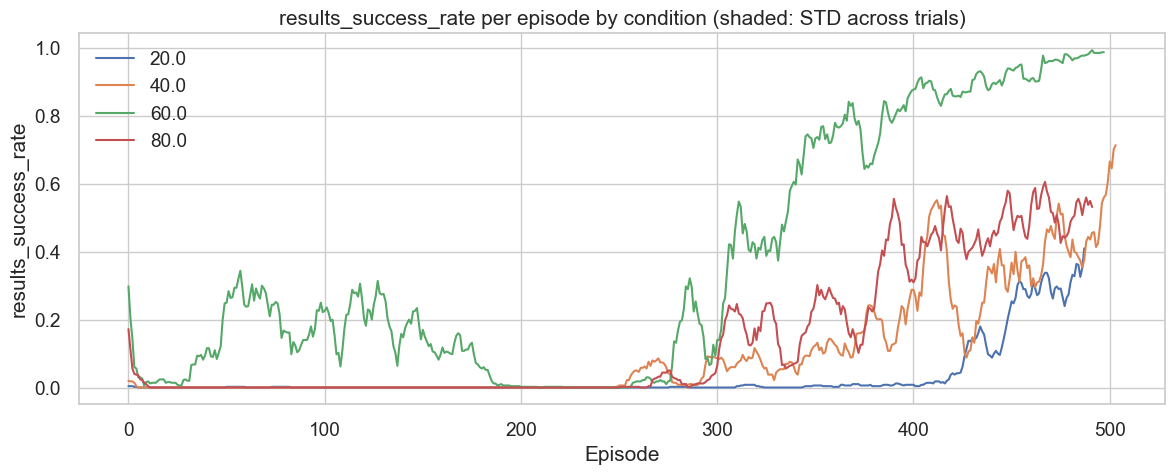

In [252]:
import matplotlib.pyplot as plt
import numpy as np
import ast

def plot_condition_results_with_std(condition_results, metric='results_success_rate', condition_labels=None, window_size=1):
    """
    Plot the specified metric with standard deviation shaded across trials for all conditions in condition_results.
    Args:
        condition_results: dict mapping condition names to DataFrames.
        metric: string, the metric column to plot (e.g. 'results_success_rate').
        condition_labels: optional, list of labels to display instead of dict keys.
        window_size: int, window size for moving average.
    """
    def moving_average(arr, window_size=50):
        arr = np.array(arr, dtype=float)
        if len(arr) < window_size:
            return arr
        ret = np.cumsum(np.nan_to_num(arr), dtype=float)
        ret[window_size:] = ret[window_size:] - ret[:-window_size]
        return ret[window_size - 1:] / window_size

    def moving_std(arrs, window_size=50):
        """Calculate std across trials for each timepoint (smoothed)."""
        arrs = np.array(arrs, dtype=float)
        if arrs.shape[0] < 2:
            # only one trial, std is zeros
            return np.zeros(arrs.shape[1])
        # moving std across trials for each step across all trials
        return np.nanstd(arrs, axis=0)
    
    plt.figure(figsize=(12,5))
    for idx, (cond, df) in enumerate(condition_results.items()):
        if df.empty:
            continue
        all_metric_series = []
        for val in df[metric]:
            if isinstance(val, str):
                try:
                    arr = ast.literal_eval(val)
                except Exception:
                    arr = []
            else:
                arr = val
            all_metric_series.append(np.array(arr, dtype=np.float32))
        if not all_metric_series:
            continue
        # Pad all series to the same length
        max_len = max(len(arr) for arr in all_metric_series)
        padded = [np.pad(arr, (0, max_len - len(arr)), constant_values=np.nan) for arr in all_metric_series]
        stacked = np.vstack(padded)  # shape: (num_trials, num_episodes)
        
        # Compute mean and STD across trials, then moving-average them (axis=1: episode axis)
        ma_stacked = np.array([moving_average(row, window_size) for row in stacked])
        mean = np.nanmean(ma_stacked, axis=0)
        std = np.nanstd(ma_stacked, axis=0)
        steps = np.arange(len(mean))
        
        label = condition_labels[idx] if condition_labels is not None else cond
        plt.plot(steps, mean, label=label)
        plt.fill_between(steps, mean - std, mean + std, alpha=0.2)

    plt.xlabel('Episode')
    plt.ylabel(metric)
    plt.title(f'{metric} per episode by condition (shaded: STD across trials)')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_condition_results_with_std(condition_results, window_size=10)

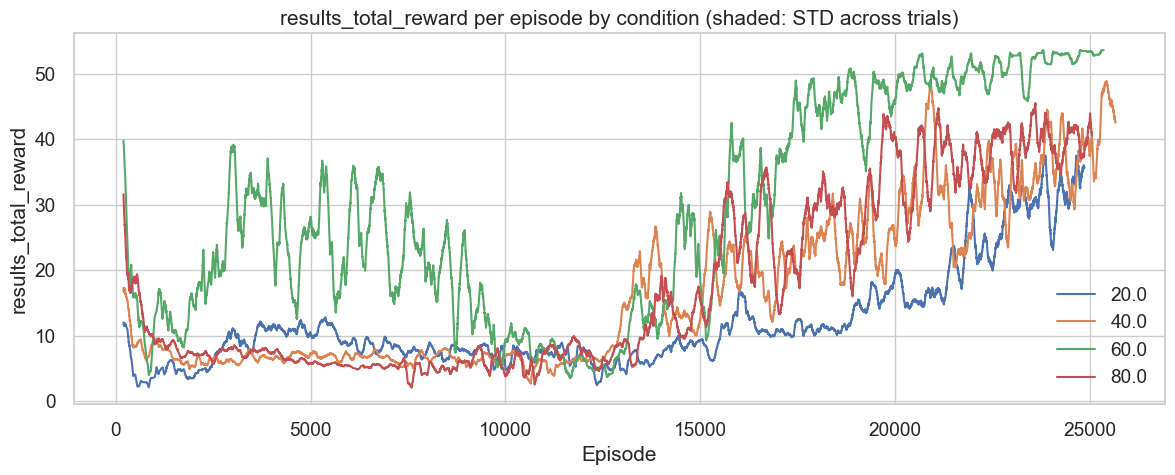

In [253]:
import matplotlib.pyplot as plt
import numpy as np
import ast

def plot_condition_results_std_across_trials(condition_results, metric='results_total_reward', condition_labels=None, window_size=50):
    """
    Plot the mean and std (across trials) of the specified metric for all conditions in condition_results.
    Args:
        condition_results: dict mapping condition names to DataFrames.
        metric: string, e.g., 'results_success_rate'.
        condition_labels: optional, list of labels for legend.
        window_size: int, window size for moving average.
    """
    def moving_average(arr, window_size=50):
        arr = np.array(arr, dtype=float)
        if len(arr) < window_size:
            return arr
        ret = np.cumsum(np.nan_to_num(arr), dtype=float)
        ret[window_size:] = ret[window_size:] - ret[:-window_size]
        return ret[window_size - 1:] / window_size

    plt.figure(figsize=(12,5))
    for idx, (cond, df) in enumerate(condition_results.items()):
        if df.empty:
            continue
        all_metric_series = []
        for val in df[metric]:
            if isinstance(val, str):
                try:
                    arr = ast.literal_eval(val)
                except Exception:
                    arr = []
            else:
                arr = val
            all_metric_series.append(np.array(arr, dtype=np.float32))
        if not all_metric_series:
            continue
        max_len = max(len(arr) for arr in all_metric_series)
        padded = [np.pad(arr, (0, max_len - len(arr)), constant_values=np.nan) for arr in all_metric_series]
        stacked = np.vstack(padded)  # shape: (num_trials, num_episodes)

        # Moving average the trials (per trial, across episodes)
        smoothed_trials = [moving_average(row, window_size) for row in stacked]
        min_len = min(len(row) for row in smoothed_trials)
        # Truncate to minimum length after moving average so shapes match
        smoothed_trials = [row[:min_len] for row in smoothed_trials]
        smoothed_trials = np.vstack(smoothed_trials)
        mean_across_trials = np.nanmean(smoothed_trials, axis=0)
        std_across_trials = np.nanstd(smoothed_trials, axis=0) if smoothed_trials.shape[0] > 1 else np.zeros_like(mean_across_trials)
        steps = np.arange(len(mean_across_trials)) + (window_size - 1)

        label = condition_labels[idx] if condition_labels is not None else cond
        plt.plot(steps, mean_across_trials, label=label)
        plt.fill_between(steps, mean_across_trials - std_across_trials, mean_across_trials + std_across_trials, alpha=0.2)

    plt.xlabel('Episode')
    plt.ylabel(metric)
    plt.title(f'{metric} per episode by condition (shaded: STD across trials)')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_condition_results_std_across_trials(condition_results, window_size=200)